# 🏠 House Price Prediction — Hyperparameter Tuning
## Objectif
Trouver les meilleurs paramètres pour chaque modèle avec GridSearchCV
avant de les entraîner dans le notebook de modélisation.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.linear_model import ElasticNet
import lightgbm as lgb
from sklearn.linear_model import ElasticNet
import lightgbm as lgb

# Charger les données preprocessées
X = pd.read_csv('../data/processed/X_scaled.csv')
y = pd.read_csv('../data/processed/y.csv').squeeze()

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (1166, 326)
Test : (292, 326)


## 1. Ridge — Recherche des meilleurs paramètres

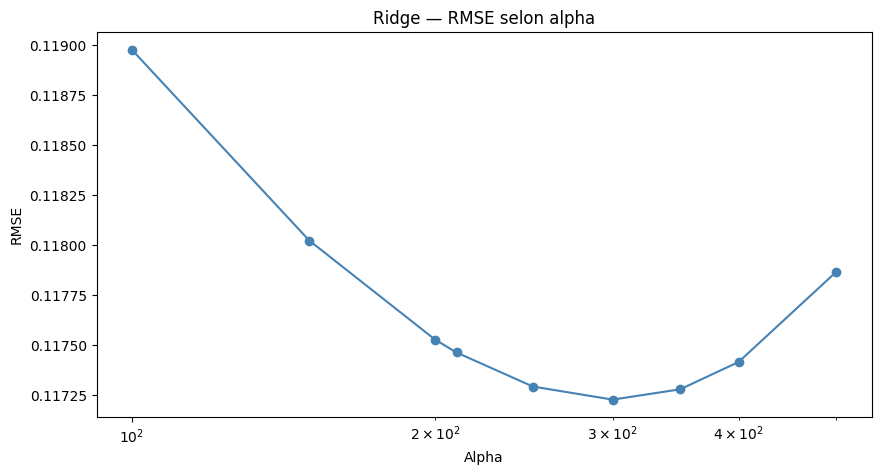

Meilleur alpha : 300
Meilleur RMSE : 0.1172


In [81]:
# Recherche manuelle du meilleur alpha pour Ridge
alphas = [100, 150, 200, 210, 250, 300, 350, 400, 500]
rmse_scores = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    scores = cross_val_score(model, X_train, y_train, 
                             cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    rmse_scores.append(rmse)

# Tracer la courbe
plt.figure(figsize=(10, 5))
plt.plot(alphas, rmse_scores, marker='o', color='steelblue')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.title('Ridge — RMSE selon alpha')
plt.show()

# Meilleur alpha
best_alpha = alphas[np.argmin(rmse_scores)]
print("Meilleur alpha :", best_alpha)
print("Meilleur RMSE :", round(min(rmse_scores), 4))

## 2. Lasso — Recherche des meilleurs paramètres

C:\Users\amine\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.032e+00, tolerance: 1.492e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\amine\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.022e-01, tolerance: 1.519e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\amine\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\loca

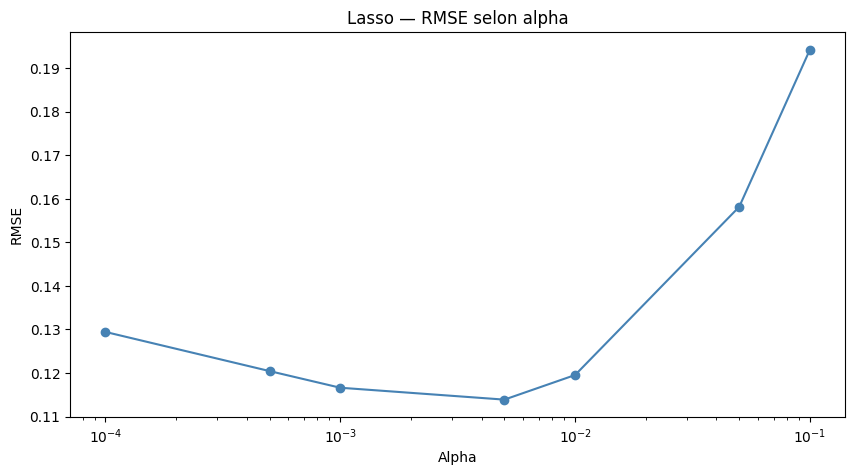

Meilleur alpha : 0.005
Meilleur RMSE : 0.1139


In [82]:
# Recherche manuelle du meilleur alpha pour Lasso
alphas = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
rmse_scores = []

for alpha in alphas:
    model = Lasso(alpha=alpha)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    rmse_scores.append(rmse)

# Tracer la courbe
plt.figure(figsize=(10, 5))
plt.plot(alphas, rmse_scores, marker='o', color='steelblue')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.title('Lasso — RMSE selon alpha')
plt.show()

# Meilleur alpha
best_alpha = alphas[np.argmin(rmse_scores)]
print("Meilleur alpha :", best_alpha)
print("Meilleur RMSE :", round(min(rmse_scores), 4))

## 3. Random Forest — Recherche des meilleurs paramètres

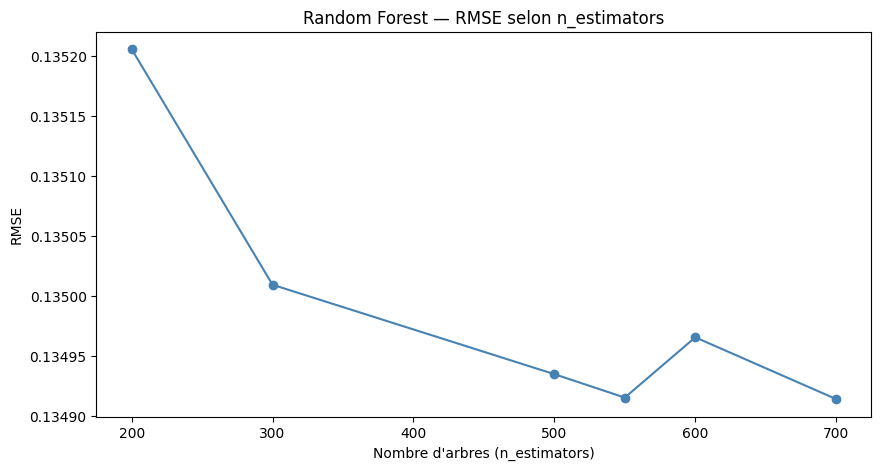

Meilleur n_estimators : 700
Meilleur RMSE : 0.1349


In [83]:
# Recherche manuelle pour Random Forest
n_estimators_list = [ 200, 300, 500,550 , 600, 700]
rmse_scores = []

for n in n_estimators_list:
    model = RandomForestRegressor(n_estimators=n, random_state=30)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    rmse_scores.append(rmse)

# Tracer la courbe
plt.figure(figsize=(10, 5))
plt.plot(n_estimators_list, rmse_scores, marker='o', color='steelblue')
plt.xlabel('Nombre d\'arbres (n_estimators)')
plt.ylabel('RMSE')
plt.title('Random Forest — RMSE selon n_estimators')
plt.show()

# Meilleur paramètre
best_n = n_estimators_list[np.argmin(rmse_scores)]
print("Meilleur n_estimators :", best_n)
print("Meilleur RMSE :", round(min(rmse_scores), 4))

## 4. XGBoost — Recherche des meilleurs paramètres

Meilleur learning_rate : 0.1
Meilleur max_depth : 3
Meilleur n_estimators : 500
Meilleur subsample : 0.8


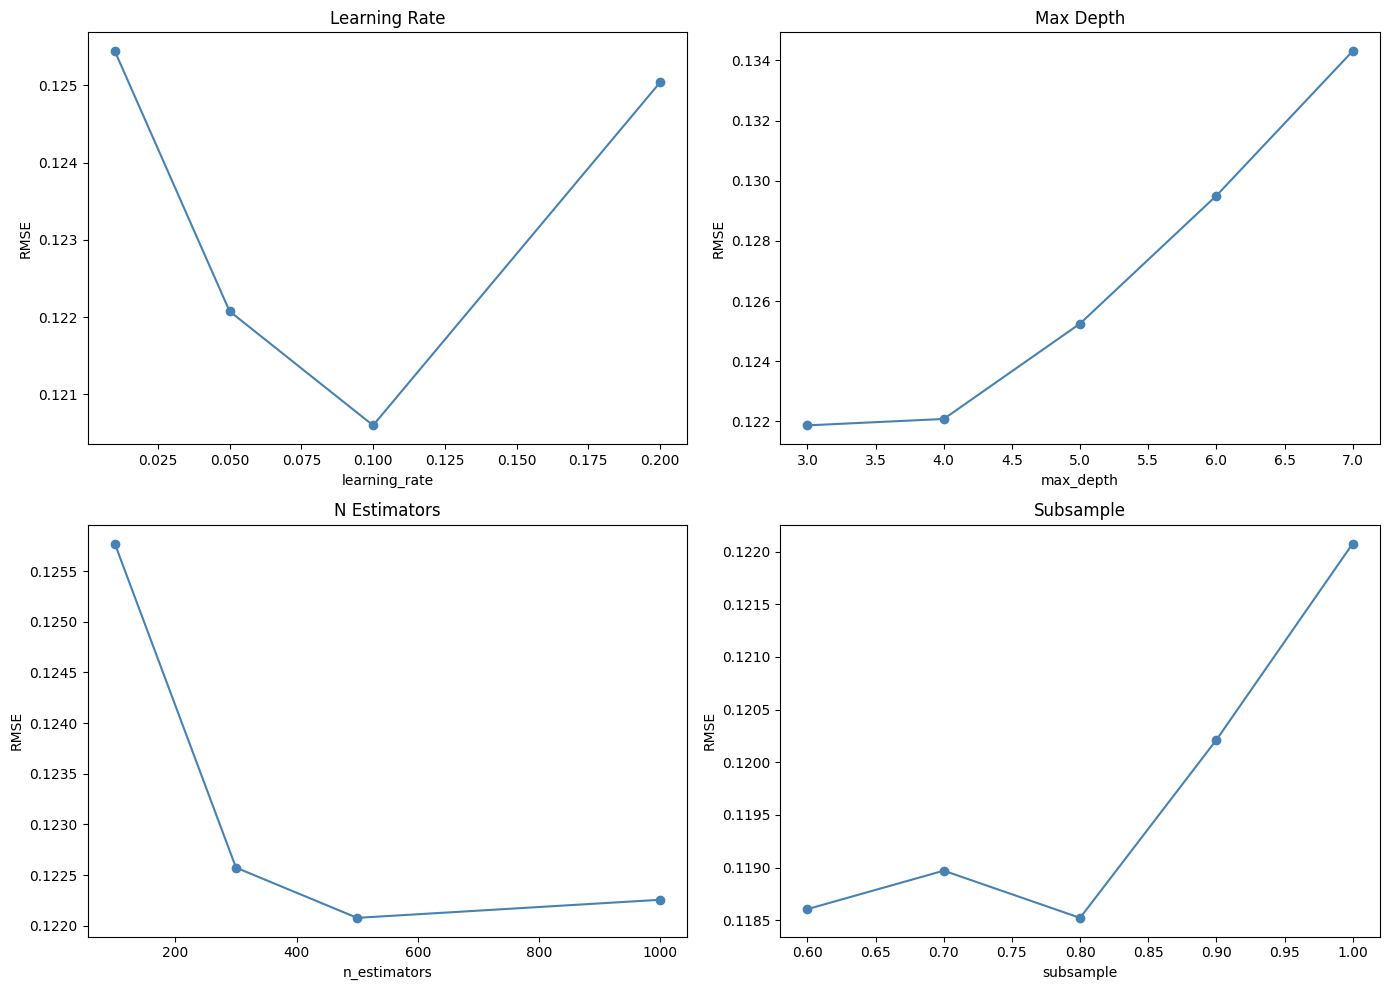


── Résumé ──
learning_rate : 0.1
max_depth     : 3
n_estimators  : 500
subsample     : 0.8


In [84]:
# Recherche manuelle pour XGBoost 
# ── Paramètres à tester ──
learning_rates  = [0.01, 0.05, 0.1, 0.2]
max_depths      = [3, 4, 5, 6, 7]
n_estimators    = [100, 300, 500, 1000]
subsamples      = [0.6, 0.7, 0.8, 0.9, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── 1. Learning Rate ──
rmse_lr = []
for lr in learning_rates:
    model = XGBRegressor(n_estimators=500, learning_rate=lr,
                         max_depth=4, random_state=30, verbosity=0)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='neg_mean_squared_error')
    rmse_lr.append(np.sqrt(-scores.mean()))

axes[0,0].plot(learning_rates, rmse_lr, marker='o', color='steelblue')
axes[0,0].set_title('Learning Rate')
axes[0,0].set_xlabel('learning_rate')
axes[0,0].set_ylabel('RMSE')
best_lr = learning_rates[np.argmin(rmse_lr)]
print("Meilleur learning_rate :", best_lr)

# ── 2. Max Depth ──
rmse_depth = []
for depth in max_depths:
    model = XGBRegressor(n_estimators=500, learning_rate=0.05,
                         max_depth=depth, random_state=30, verbosity=0)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='neg_mean_squared_error')
    rmse_depth.append(np.sqrt(-scores.mean()))

axes[0,1].plot(max_depths, rmse_depth, marker='o', color='steelblue')
axes[0,1].set_title('Max Depth')
axes[0,1].set_xlabel('max_depth')
axes[0,1].set_ylabel('RMSE')
best_depth = max_depths[np.argmin(rmse_depth)]
print("Meilleur max_depth :", best_depth)

# ── 3. N Estimators ──
rmse_n = []
for n in n_estimators:
    model = XGBRegressor(n_estimators=n, learning_rate=0.05,
                         max_depth=4, random_state=30, verbosity=0)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='neg_mean_squared_error')
    rmse_n.append(np.sqrt(-scores.mean()))

axes[1,0].plot(n_estimators, rmse_n, marker='o', color='steelblue')
axes[1,0].set_title('N Estimators')
axes[1,0].set_xlabel('n_estimators')
axes[1,0].set_ylabel('RMSE')
best_n = n_estimators[np.argmin(rmse_n)]
print("Meilleur n_estimators :", best_n)

# ── 4. Subsample ──
rmse_sub = []
for sub in subsamples:
    model = XGBRegressor(n_estimators=500, learning_rate=0.05,
                         max_depth=4, subsample=sub,
                         random_state=30, verbosity=0)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='neg_mean_squared_error')
    rmse_sub.append(np.sqrt(-scores.mean()))

axes[1,1].plot(subsamples, rmse_sub, marker='o', color='steelblue')
axes[1,1].set_title('Subsample')
axes[1,1].set_xlabel('subsample')
axes[1,1].set_ylabel('RMSE')
best_sub = subsamples[np.argmin(rmse_sub)]
print("Meilleur subsample :", best_sub)

plt.tight_layout()
plt.show()

print("\n── Résumé ──")
print(f"learning_rate : {best_lr}")
print(f"max_depth     : {best_depth}")
print(f"n_estimators  : {best_n}")
print(f"subsample     : {best_sub}")

## 5. ElasticNet — Recherche des meilleurs paramètres

C:\Users\amine\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.289e-02, tolerance: 1.492e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\amine\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.757e-02, tolerance: 1.480e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\amine\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\loca

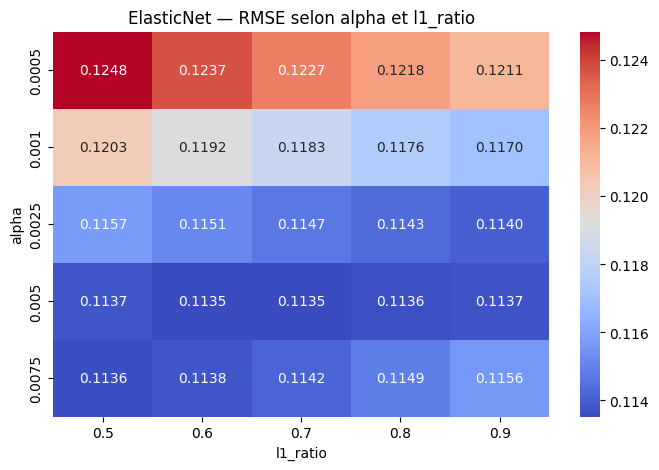

Meilleur alpha : 0.005
Meilleur l1_ratio : 0.6


In [ ]:
alphas = [0.0005, 0.001, 0.0025, 0.005, 0.0075 ]
l1_ratios = [0.5, 0.6, 0.7, 0.8, 0.9]
rmse_scores = []

for alpha in alphas:
    row = []
    for l1 in l1_ratios:
        model = ElasticNet(alpha=alpha, l1_ratio=l1)
        scores = cross_val_score(model, X_train, y_train,
                                 cv=5, scoring='neg_mean_squared_error')
        row.append(np.sqrt(-scores.mean()))
    rmse_scores.append(row)

# Heatmap
import seaborn as sns
rmse_df = pd.DataFrame(rmse_scores, index=alphas, columns=l1_ratios)
plt.figure(figsize=(8, 5))
sns.heatmap(rmse_df, annot=True, fmt='.4f', cmap='coolwarm')
plt.title('ElasticNet — RMSE selon alpha et l1_ratio')
plt.xlabel('l1_ratio')
plt.ylabel('alpha')
plt.show()

best_idx = np.unravel_index(np.argmin(rmse_scores), np.array(rmse_scores).shape)
print("Meilleur alpha :", alphas[best_idx[0]])
print("Meilleur l1_ratio :", l1_ratios[best_idx[1]])

## 6. LightGBM — Recherche des meilleurs paramètres

Meilleur num_leaves : 10
Meilleur learning_rate : 0.05
Meilleur n_estimators : 720
Meilleur min_child_samples : 20


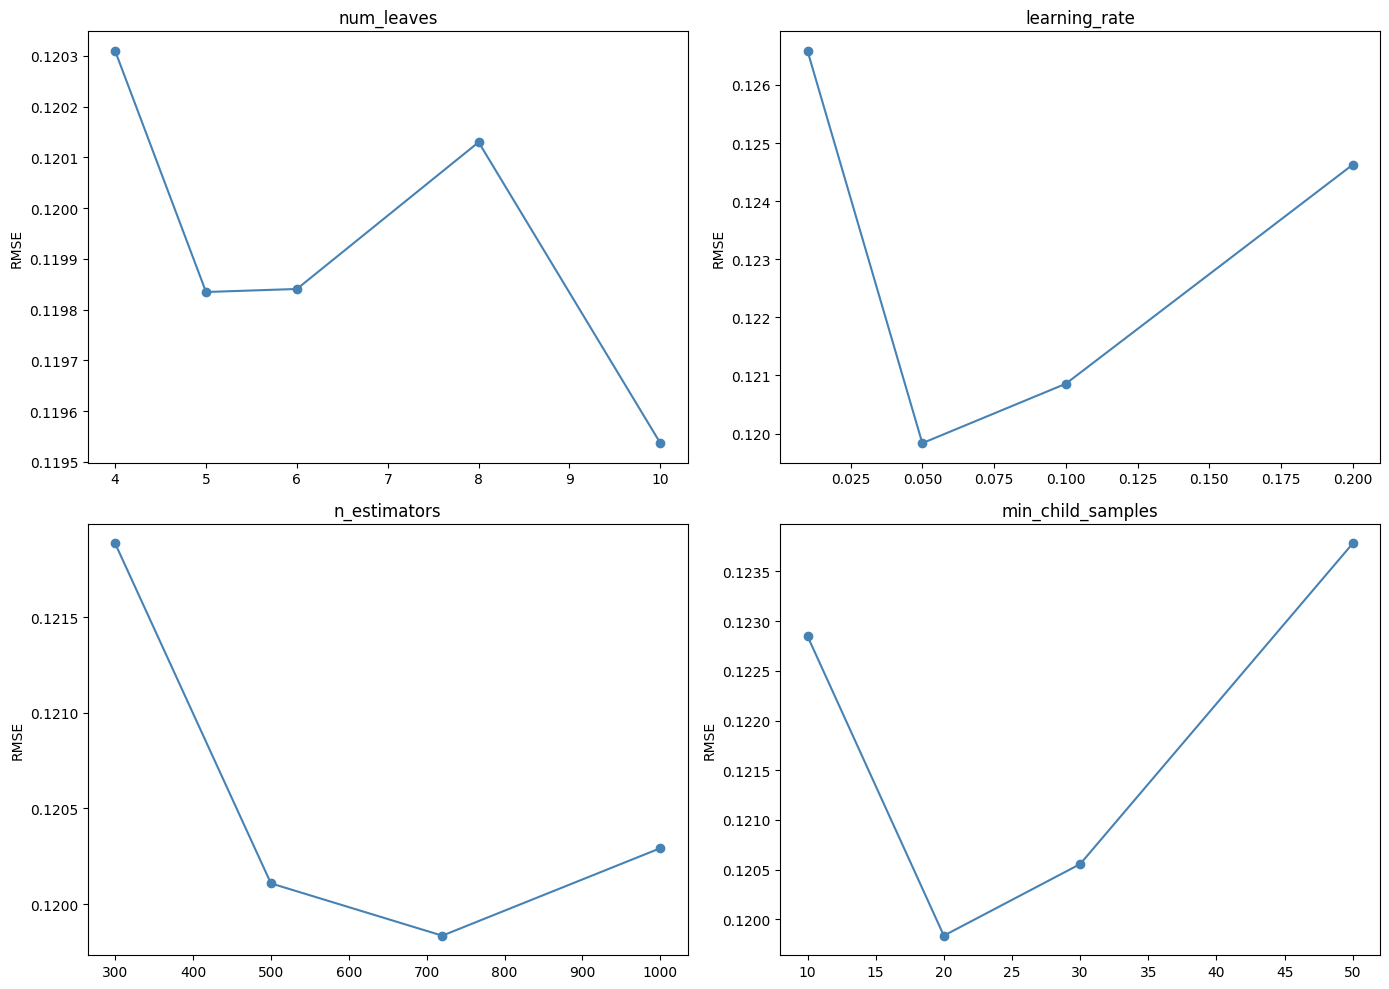


── Résumé LightGBM ──
num_leaves        : 10
learning_rate     : 0.05
n_estimators      : 720
min_child_samples : 20


In [ ]:
# 4 paramètres à tester séparément
num_leaves_list = [4, 5, 6, 8, 10]
learning_rates = [0.01, 0.05, 0.1, 0.2]
n_estimators_list = [300, 500, 720, 1000]
min_child_samples_list = [10, 20, 30, 50]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. num_leaves
rmse_nl = []
for nl in num_leaves_list:
    model = lgb.LGBMRegressor(n_estimators=720, learning_rate=0.05,
                               num_leaves=nl, random_state=30, verbose=-1)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='neg_mean_squared_error')
    rmse_nl.append(np.sqrt(-scores.mean()))

axes[0,0].plot(num_leaves_list, rmse_nl, marker='o', color='steelblue')
axes[0,0].set_title('num_leaves')
axes[0,0].set_ylabel('RMSE')
best_nl = num_leaves_list[np.argmin(rmse_nl)]
print("Meilleur num_leaves :", best_nl)

# 2. learning_rate
rmse_lr = []
for lr in learning_rates:
    model = lgb.LGBMRegressor(n_estimators=720, learning_rate=lr,
                               num_leaves=5, random_state=30, verbose=-1)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='neg_mean_squared_error')
    rmse_lr.append(np.sqrt(-scores.mean()))

axes[0,1].plot(learning_rates, rmse_lr, marker='o', color='steelblue')
axes[0,1].set_title('learning_rate')
axes[0,1].set_ylabel('RMSE')
best_lr = learning_rates[np.argmin(rmse_lr)]
print("Meilleur learning_rate :", best_lr)

# 3. n_estimators
rmse_n = []
for n in n_estimators_list:
    model = lgb.LGBMRegressor(n_estimators=n, learning_rate=0.05,
                               num_leaves=5, random_state=30, verbose=-1)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='neg_mean_squared_error')
    rmse_n.append(np.sqrt(-scores.mean()))

axes[1,0].plot(n_estimators_list, rmse_n, marker='o', color='steelblue')
axes[1,0].set_title('n_estimators')
axes[1,0].set_ylabel('RMSE')
best_n = n_estimators_list[np.argmin(rmse_n)]
print("Meilleur n_estimators :", best_n)

# 4. min_child_samples
rmse_mcs = []
for mcs in min_child_samples_list:
    model = lgb.LGBMRegressor(n_estimators=720, learning_rate=0.05,
                               num_leaves=5, min_child_samples=mcs,
                               random_state=30, verbose=-1)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='neg_mean_squared_error')
    rmse_mcs.append(np.sqrt(-scores.mean()))

axes[1,1].plot(min_child_samples_list, rmse_mcs, marker='o', color='steelblue')
axes[1,1].set_title('min_child_samples')
axes[1,1].set_ylabel('RMSE')
best_mcs = min_child_samples_list[np.argmin(rmse_mcs)]
print("Meilleur min_child_samples :", best_mcs)

plt.tight_layout()
plt.show()

print("\n── Résumé LightGBM ──")
print(f"num_leaves        : {best_nl}")
print(f"learning_rate     : {best_lr}")
print(f"n_estimators      : {best_n}")
print(f"min_child_samples : {best_mcs}")

## 7. Comparaison finale des meilleurs modèles

In [17]:
# Entraîner chaque modèle avec ses meilleurs paramètres
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=300),
    'Lasso': Lasso(alpha=0.005),
    'Random Forest': RandomForestRegressor(n_estimators=700, random_state=30),
    'XGBoost': XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=3, random_state=30,subsample=0.8),
    'ElasticNet': ElasticNet(alpha=0.005, l1_ratio=0.7),
    'LightGBM': lgb.LGBMRegressor(n_estimators=720, learning_rate=0.05, num_leaves=10, random_state=30,min_child_samples=20, verbose=-1)

}

results = {}

for name, model in models.items():
    # Entraînement
    model.fit(X_train, y_train)
    
    # Prédiction
    y_pred = model.predict(X_test)
    
    # Métriques
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'RMSE': round(rmse, 4), 'R²': round(r2, 4)}
    print(f"{name} → RMSE: {rmse:.4f} | R²: {r2:.4f}")

Linear Regression → RMSE: 0.1738 | R²: 0.8158
Ridge → RMSE: 0.1230 | R²: 0.9077
Lasso → RMSE: 0.1192 | R²: 0.9133
Random Forest → RMSE: 0.1454 | R²: 0.8711
XGBoost → RMSE: 0.1294 | R²: 0.8979
ElasticNet → RMSE: 0.1187 | R²: 0.9140
LightGBM → RMSE: 0.1308 | R²: 0.8956


C:\Users\amine\AppData\Local\Temp\ipykernel_800\2429734776.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['RMSE'], palette='coolwarm', ax=ax1)
C:\Users\amine\AppData\Local\Temp\ipykernel_800\2429734776.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['R²'], palette='coolwarm', ax=ax2)


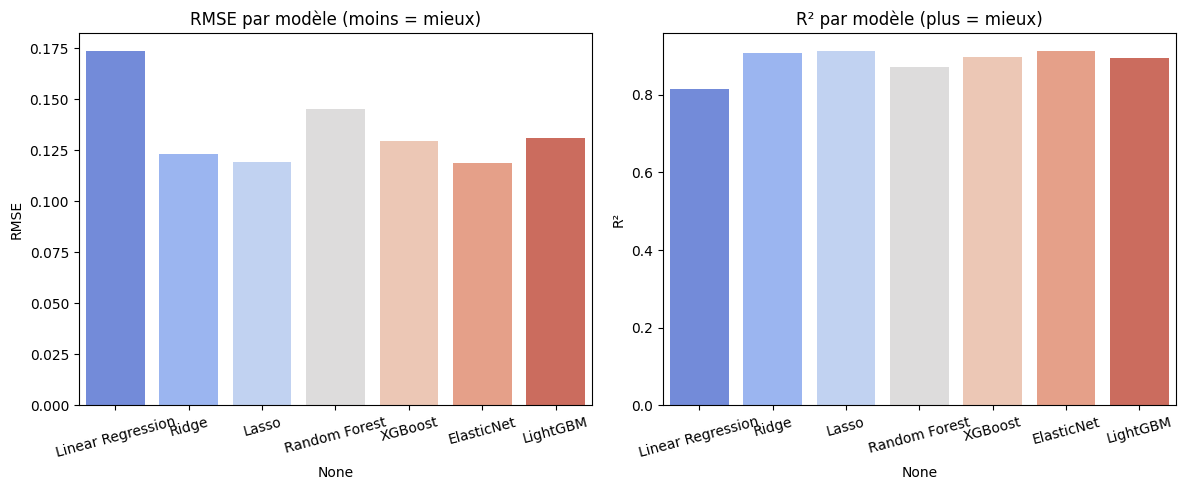

In [18]:
# Visualisation des résultats
results_df = pd.DataFrame(results).T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# RMSE
sns.barplot(x=results_df.index, y=results_df['RMSE'], palette='coolwarm', ax=ax1)
ax1.set_title('RMSE par modèle (moins = mieux)')
ax1.set_ylabel('RMSE')
ax1.tick_params(axis='x', rotation=15)

# R²
sns.barplot(x=results_df.index, y=results_df['R²'], palette='coolwarm', ax=ax2)
ax2.set_title('R² par modèle (plus = mieux)')
ax2.set_ylabel('R²')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Stacking — Combinaison des meilleurs modèles

In [19]:
from sklearn.ensemble import StackingRegressor

# Modèles de base
base_models = [
    ('elasticnet', ElasticNet(alpha=0.005, l1_ratio=0.7)),
    ('lasso', Lasso(alpha=0.005)),
    ('ridge', Ridge(alpha=300)),
    ('lgbm', lgb.LGBMRegressor(n_estimators=720, learning_rate=0.05,num_leaves=5, random_state=10, verbose=-1)),
    ('xgb', XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=3, random_state=30,subsample=0.8))
]

# Méta-apprenant
stacking = StackingRegressor(
    estimators=base_models,
    final_estimator=Lasso(alpha=0.005),
    cv=5
)

stacking.fit(X_train, y_train)
y_pred = stacking.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Stacking → RMSE: {rmse:.4f} | R²: {r2:.4f}")

Stacking → RMSE: 0.1184 | R²: 0.9144


In [20]:
from scipy.optimize import minimize

# Prédictions de chaque modèle
pred_stacking = stacking.predict(X_test)
pred_elasticnet = models['ElasticNet'].predict(X_test)
pred_lasso = models['Lasso'].predict(X_test)
pred_ridge = models['Ridge'].predict(X_test)
pred_xgb = models['XGBoost'].predict(X_test)
pred_lgbm = models['LightGBM'].predict(X_test)

# Optimisation des poids
def objective(weights):
    pred = (weights[0] * pred_stacking +
            weights[1] * pred_elasticnet +
            weights[2] * pred_lasso +
            weights[3] * pred_ridge +
            weights[4] * pred_xgb +
            weights[5] * pred_lgbm)
    return np.sqrt(mean_squared_error(y_test, pred))

# Contrainte : somme des poids = 1
constraints = {'type': 'eq', 'fun': lambda w: w.sum() - 1}
bounds = [(0, 1)] * 6

# Point de départ : poids égaux
x0 = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]

result = minimize(objective, x0=x0, bounds=bounds, constraints=constraints)

print("Meilleurs poids :")
print(f"  Stacking    : {result.x[0]:.4f}")
print(f"  ElasticNet  : {result.x[1]:.4f}")
print(f"  Lasso       : {result.x[2]:.4f}")
print(f"  Ridge       : {result.x[3]:.4f}")
print(f"  XGBoost     : {result.x[4]:.4f}")
print(f"  LightGBM    : {result.x[5]:.4f}")
print(f"\nMeilleur RMSE : {result.fun:.4f}")

Meilleurs poids :
  Stacking    : 0.2183
  ElasticNet  : 0.3376
  Lasso       : 0.2797
  Ridge       : 0.0099
  XGBoost     : 0.0977
  LightGBM    : 0.0568

Meilleur RMSE : 0.1179


In [21]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Sauvegarder tous les modèles et les poids
joblib.dump(stacking, '../models/stacking.pkl')
joblib.dump(models['ElasticNet'], '../models/elasticnet.pkl')
joblib.dump(models['Lasso'], '../models/lasso.pkl')
joblib.dump(models['Ridge'], '../models/ridge.pkl')
joblib.dump(models['XGBoost'], '../models/xgboost.pkl')
joblib.dump(models['LightGBM'], '../models/lgbm.pkl')
joblib.dump(result.x, '../models/blend_weights.pkl')

print("Modèles sauvegardés !")

Modèles sauvegardés !
